In [1]:
import pandas as pd
import numpy as np

import re

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf


Matplotlib is building the font cache; this may take a moment.


In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from collections import Counter

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [4]:
df = pd.read_csv("tweet_emotions.csv")
df.head()

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habit earlier and i started freakin at his part =[
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin on your call...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,"@dannycastillo We want to trade with someone who has Houston tickets, but no one will."


In [5]:
df.shape

(40000, 3)

In [6]:
print(df.columns)

Index(['tweet_id', 'sentiment', 'content'], dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweet_id   40000 non-null  int64
 1   sentiment  40000 non-null  str  
 2   content    40000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 937.6 KB


In [8]:
df.describe(include = "all")

,tweet_id,sentiment,content
count,4.000000e+04,40000,40000
unique,NaN,13,39827
top,NaN,neutral,I just received a mothers day card from my lovely daughter wishing my a happy mothers day http://tr.im/kWK9
freq,NaN,8638,14
mean,1.845184e+09,NaN,NaN
std,1.188579e+08,NaN,NaN
min,1.693956e+09,NaN,NaN
25%,1.751431e+09,NaN,NaN
50%,1.855443e+09,NaN,NaN
75%,1.962781e+09,NaN,NaN


In [9]:
df.sample(10, random_state = 42)

,tweet_id,sentiment,content
32823,1752414968,neutral,Good Morning
16298,1965295852,empty,"I just put my computer up on craigslist. I've had the same case, monitor, and speakers for over 5 years."
28505,1696219218,love,in ten minutes shopping demi lovato-back around demi lovato-behind enemy lines have you all seen the titanic 2 trailer? its really good!
6689,1961416554,neutral,From twitterberry moved to ubertwitter - suffered from BB cache errors
26893,1695580473,sadness,@thriftymom TEAR*
36572,1753331093,happiness,Ps... I got Ben Button today... completes my Best Picture noms....got all 5 now. It was a GREAT year!!
12335,1963544918,worry,"Just fell asleep for 2 &amp; 1/2 hours so missed both chances for first-look Hollyoaks, ugh"
29591,1751287108,happiness,"@VanetaRogers Thank ye, Vaneta. Much appreciated"
18948,1966120040,sadness,@donttreeriddle Oh noes!! Melted ice cream = do not want.
31067,1751819700,relief,@orphanth i just had pasta from pizzahut.


In [10]:
number_of_classes = df['sentiment'].nunique()
print(f"Number of sentiment classes: {number_of_classes} ")

Number of sentiment classes: 13 


In [11]:
sentiment_classes = df['sentiment'].unique()
print(sentiment_classes)

<StringArray>
[     'empty',    'sadness', 'enthusiasm',    'neutral',      'worry',
   'surprise',       'love',        'fun',       'hate',  'happiness',
    'boredom',     'relief',      'anger']
Length: 13, dtype: str


In [12]:
class_count = df['sentiment'].value_counts()
print(class_count)

sentiment
neutral       8638
worry         8459
happiness     5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


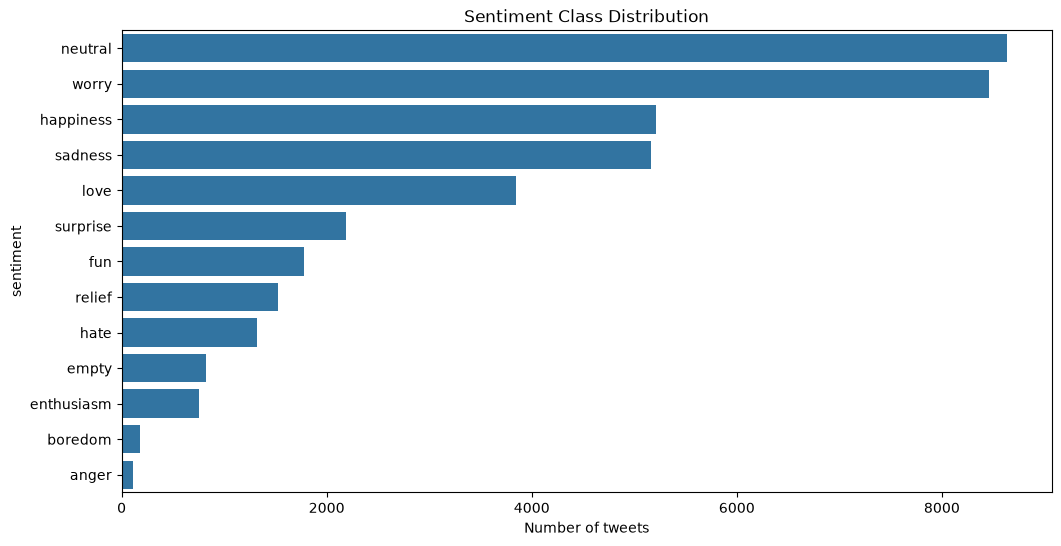

In [13]:
plt.figure(figsize = (12,6))
sns.countplot(data = df, y = "sentiment", order = df["sentiment"].value_counts().index)
plt.title("Sentiment Class Distribution")
plt.xlabel("Number of tweets")
plt.ylabel("sentiment")
plt.show()

In [14]:
print(df.isnull().sum())

tweet_id     0
sentiment    0
content      0
dtype: int64


In [15]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)

0


In [16]:
text_duplicate = df[df["content"].duplicated()]
print(len(text_duplicate))

173


In [17]:
print(text_duplicate)

         tweet_id  sentiment                                        content
366    1957048870      worry             I feel so deflated. No more doggy.
521    1957088574      worry          Somebody please save the polar bears!
1026   1957198430    neutral                                    I'm at work
3684   1958103183    sadness      @dublins98dave me too! I am down 400 euro
4363   1960336689      worry        is upset, I left my phone at home again
...           ...        ...                                            ...
39859  1753886681       love                              Happy Mothers Day
39898  1753902524       love                             happy mothers day!
39913  1753902827  happiness                            happy mother's day!
39915  1753903008       love                    happy mother's day everyone
39945  1753903727       love  Happy Mother's Day to all the moms out there!

[173 rows x 3 columns]


In [18]:
df = df.drop_duplicates(subset= ["content"], keep = "first")

In [19]:
print(df.shape)

(39827, 3)


In [20]:
empty_tweets = (df["content"].fillna("").str.strip().eq("").sum())

print(f"Empty tweets:{empty_tweets}")

Empty tweets:0


In [21]:
df["char_count"] = (df["content"].fillna("").astype(str).apply(len))

In [22]:
df["word_count"] = (df["content"].fillna("").astype(str).apply(lambda x: len(x.split())))

In [23]:
df[['char_count','word_count']].describe()

,char_count,word_count
count,39827.000000,39827.000000
mean,73.530821,13.242599
std,36.490448,6.962728
min,1.000000,1.000000
25%,43.000000,7.000000
50%,69.000000,12.000000
75%,103.000000,19.000000
max,167.000000,34.000000


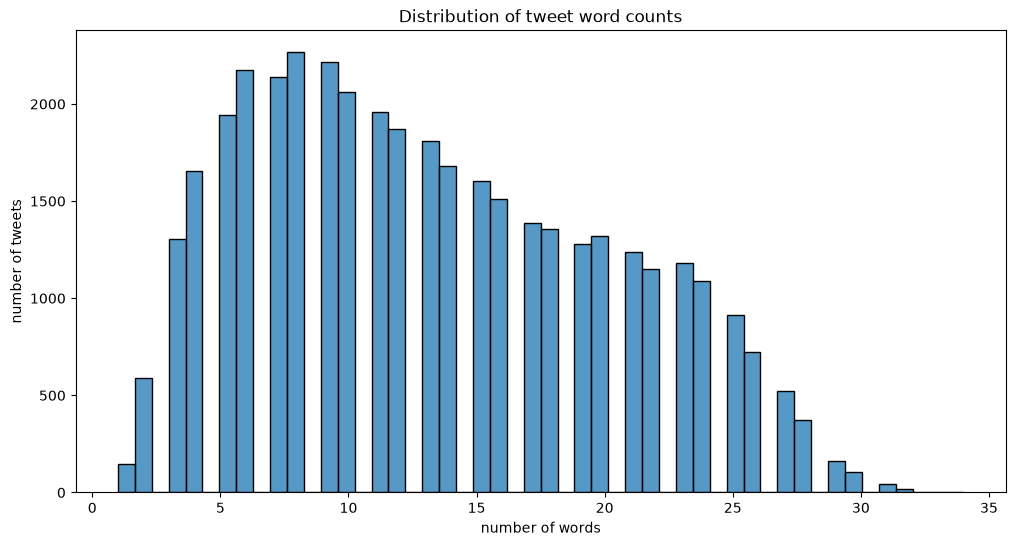

In [24]:
plt.figure(figsize = (12,6))

sns.histplot(data= df, x= "word_count", bins = 50)
plt.title("Distribution of tweet word counts")
plt.xlabel("number of words")
plt.ylabel("number of tweets")

plt.show()


In [25]:
df.nsmallest(20, "word_count")[["sentiment","content","word_count"]]

,sentiment,content,word_count
98,neutral,PrinceCharming,1
340,empty,0,1
659,neutral,@Joshuah_Pearson,1
664,neutral,@emlevins,1
1538,neutral,Hangover,1
1539,sadness,roughnight,1
1789,neutral,food...food...FOOD!,1
2206,neutral,nothing,1
2247,neutral,assignments!,1
2311,neutral,backache,1


In [26]:
df[df["word_count"]< 3].head()

,tweet_id,sentiment,content,char_count,word_count
16,1956971170,love,@annarosekerr agreed,20,2
98,1956989561,neutral,PrinceCharming,14,1
124,1956996673,hate,@britblackbird youstinkatrespondingtotexts!,44,2
137,1957000077,neutral,miss 16'th,10,2
340,1957042734,empty,0,1,1


In [27]:
df.nlargest(20, "word_count")[["sentiment", "content", "word_count"]]

,sentiment,content,word_count
28293,worry,hahas . dam tried . just nw got exam . don know how much i will get . . but i having fun today . with my pri sch friends until 5plus . =D,34
9818,neutral,"AK, flop comes 2K6 I bet 15 get raised to 25 I call, turn is A, we check, river rag, then I check and he bets 15, I raise 15 he calls, 22",33
17027,worry,@oxEmalieexo: Lol it went okay! As far as I can tell . But then I had to do a test today for geo and I was all zoned out and got like 65%,33
1711,hate,This is exactly y I hate driving thru dandy - sittin at lights next to a car of asians who r callin out to me &amp; 1 held up a knife scum!,32
2627,sadness,"How I wish I get at least 2 days-off in a row. 1 day off is not enough to rest. 3 days on, 1 day off, 4 days on, 1 day off...Ugh!!!",32
5459,sadness,My car is in the car hospital for the nxt 7 days I gotta go pick up a loaner car b4 6! Bein without wheels 4 7day will set me back heavy!,32
7908,love,Ahhh I am sooo happy Ashley Tisdale is in Germany but I am not in Oberhausen... But i will show it in the TV at 8 o' clock yeah I love it,32
12868,love,@MadisonApril lol haha fresh to death lol ha ha I love and miss u 2 id almost given ï¿½ on u cuz u nvr respond 2me but u did today! Luv u2,32
13092,sadness,Is Home Alone Yet Again; Mam And Dad Rather Go To The Club Than Stay In With Me Or Take Me Out; Yes I Think That Proves How Loved I Am !,32
13435,neutral,@chrisettefan yep. gotta go man! i'll ttyl . . . eventually . . . sometime . . . in the future . . . hopefully . . . soon. ~ ~ ~,32


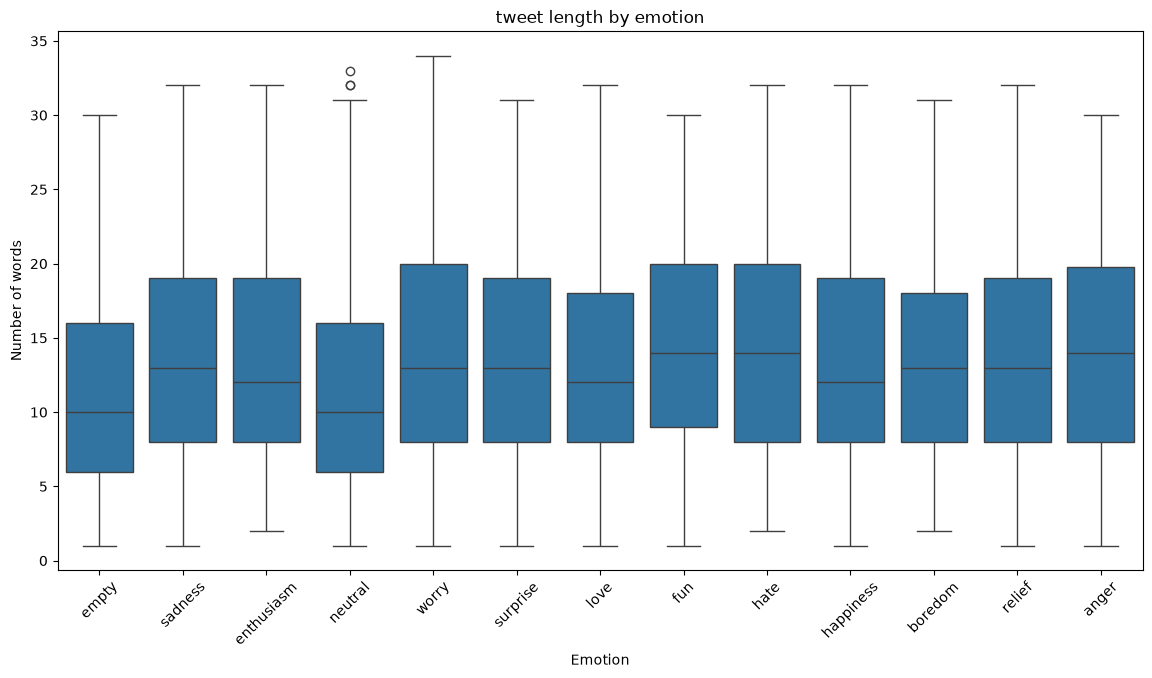

In [28]:
plt.figure(figsize = (14,7))

sns.boxplot(data = df, x = "sentiment", y= "word_count")
plt.xticks(rotation = 45)
plt.title("tweet length by emotion")
plt.xlabel("Emotion")
plt.ylabel("Number of words")
plt.show()

In [29]:
def clean_tweet(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+|www\s+","<URL>",text)

    text = re.sub(r"@\w+", " <USER> ", text)

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text

In [30]:
df["clean_text"] = df["content"].apply(clean_tweet)

In [31]:
comparison = df[["content","clean_text"]].sample(10, random_state = 42)

In [32]:
comparison

,content,clean_text
37761,the sun is shinning! im off out!!,the sun is shinning! im off out!!
1903,wow i must have been tired. i fell asleep @ exactly the start of the 10pm news &amp; now up as if its 8am.,wow i must have been tired. i fell asleep @ exactly the start of the 10pm news &amp; now up as if its 8am.
16633,@knobzie their loss,their loss
27370,@Mickey_X sorry about that.,sorry about that.
21139,@tracymacy My pleasure,my pleasure
34688,Exhausted to the tee.. So i'm knocking out! Nighty night tweety birds,exhausted to the tee.. so i'm knocking out! nighty night tweety birds
6250,"@PochaccoYoly well, I took it in early '00, graduated in '01. we were the final stage guinea pigs it seriously is a waste of time.","well, i took it in early '00, graduated in '01. we were the final stage guinea pigs it seriously is a waste of time."
33181,X-men movie was pretty good. Kinda predictable @ points but good action sequences,x-men movie was pretty good. kinda predictable @ points but good action sequences
27193,Less rain more sunshine,less rain more sunshine
24904,"Jamie @ Sean Cody, up for some angry sex?: Jamie @ Sean Cody, I wouldn't piss this one off Hey there Guys, Do.. http://tinyurl.com/ddyyd6","jamie @ sean cody, up for some angry sex?: jamie @ sean cody, i wouldn't piss this one off hey there guys, do.."


In [33]:
all_text = " ".join(df["clean_text"])

words = all_text.split()

word_counts = Counter(words)

print(word_counts.most_common(30))

[('i', 18865), ('to', 14232), ('the', 12823), ('a', 9691), ('my', 7939), ('and', 7237), ('you', 6086), ('is', 5581), ('in', 5248), ('for', 5235), ('it', 4804), ('of', 4473), ('on', 4001), ('have', 3713), ('so', 3537), ('that', 3333), ('me', 3270), ('but', 3192), ('just', 3107), ("i'm", 3102), ('with', 2912), ('be', 2837), ('at', 2673), ('was', 2601), ('not', 2500), ('day', 2137), ('this', 2130), ('all', 2077), ('get', 1985), ('good', 1937)]


In [34]:
df["mentions"] = (df["content"].astype(str).str.count(r"@\w+"))
df["urls"] = (df["content"].astype(str).str.count(r"http\S+|www\S+"))
df["hashtags"] = (df["content"].astype(str).str.count(r"#\w+"))
df["exclamation_marks"] = (df["content"].astype(str).str.count(r"!"))
df["question_marks"] = (df["content"].astype(str).str.count(r"\?"))

In [35]:
df[["mentions", "urls", "hashtags","exclamation_marks","question_marks"]].describe()

,mentions,urls,hashtags,exclamation_marks,question_marks
count,39827.000000,39827.000000,39827.000000,39827.000000,39827.000000
mean,0.501946,0.051322,0.023100,0.550506,0.168855
std,0.570553,0.226052,0.183617,1.345531,1.224237
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,1.000000,0.000000
max,10.000000,4.000000,9.000000,76.000000,98.000000


In [36]:
#prepare the target variables
#using the lable encoder
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["sentiment"])

In [37]:
#View the mapping
for number, emotion in enumerate(label_encoder.classes_):
    print(number, "=", emotion)

0 = anger
1 = boredom
2 = empty
3 = enthusiasm
4 = fun
5 = happiness
6 = hate
7 = love
8 = neutral
9 = relief
10 = sadness
11 = surprise
12 = worry


In [38]:
# sepreate data into its idnependednt and depenedet variable which will be the sentiment
# selecting x and y 
x = df["clean_text"]
y = df["label"]


In [39]:
#split dataset into 3 parts, training, validation and test part
x_train,x_test,y_train, y_test = train_test_split(x,y,test_size=0.3, random_state = 42, stratify = y)
# stratify ensures that that in both the training and test set there is the same proportion of the label
#validation set form the trainnig set 
x_train ,x_val, y_train, y_val = train_test_split(x_train,y_train,test_size = 0.2, random_state = 42, stratify = y_train)


In [40]:
# tokenise the tweets
# when we tokenise converts the words we have into numerical values because the model cant process the words 
# we dont use the enotre dictionry in order to select only the words that we need to use
max_words = 20000
tokenizer = Tokenizer(num_words = max_words,oov_token = "<OOV>")
tokenizer.fit_on_texts(x_train)

In [41]:

#how many unique words were labeled by the tokenizer

word_index = tokenizer.word_index
print(f"Vocab_size: {len(word_index)}")

Vocab_size: 22384


In [42]:
# convert the text to sequence 
# reconstructs the tweets using these ids 
x_train_seq = tokenizer.texts_to_sequences(x_train)
x_val_seq = tokenizer.texts_to_sequences(x_val)
x_test_seq = tokenizer.texts_to_sequences(x_test)



In [43]:
# choose a maximum sequence close to the max len(sentance)

In [44]:
sequence_lengths = [len(sequence) for sequence in x_train_seq]
print(pd.Series(sequence_lengths).describe())

count    22302.000000
mean        12.828177
std          7.068225
min          0.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         36.000000
dtype: float64


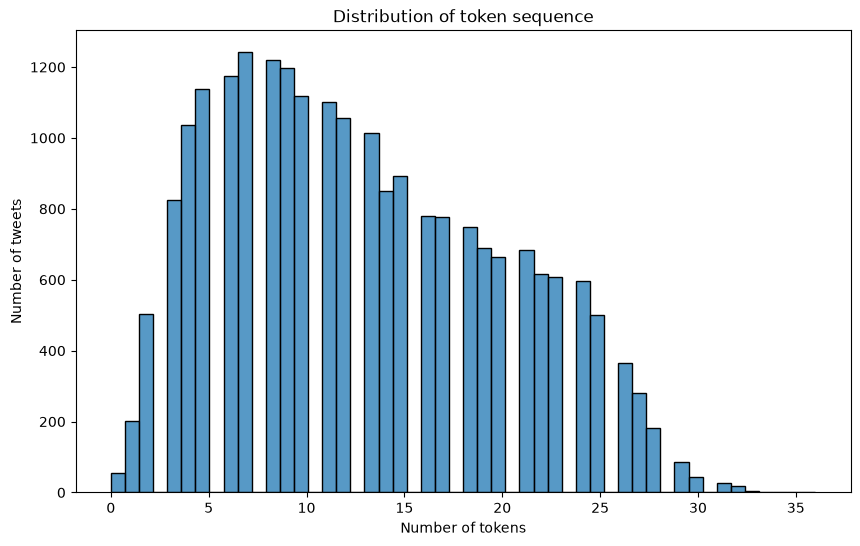

In [45]:
plt.figure(figsize = (10, 6))
sns.histplot(sequence_lengths, bins = 50)
plt.title("Distribution of token sequence")
plt.ylabel("Number of tweets")
plt.xlabel("Number of tokens")
plt.show()

In [46]:
# need to part the paragrapahs as it all has to all be the same size for the model to assert the data and actualy process the data for LSTM 
# Padding is going to cut off the tweets that are greater than the size set 
# truncating is going to cut tweets down to the right size ending up cuting of meaningful parts of the sentences
max_sequence = 50
x_train = pad_sequences(x_train_seq,maxlen = max_sequence, padding = "post", truncating = "post")
x_val = pad_sequences(x_val_seq,maxlen = max_sequence, padding = "post", truncating = "post") 
x_test = pad_sequences(x_test_seq,maxlen = max_sequence, padding = "post", truncating = "post") 

#post padding means after 

In [47]:
# find the shape of this to check the shape to make sure they all the smae size
print(f"trining_shape {x_train.shape}")
print(f"x_val_shape {x_val.shape}")
print(f"x_test_shape {x_test.shape}")

trining_shape (22302, 50)
x_val_shape (5576, 50)
x_test_shape (11949, 50)


In [63]:
# build the LSTM
# explain each layer 
# tells us that the layers will be in a sequence or one after each other 
# multiple layers that perform different tasks
# first layer is the embedding
# converts what we generated from the tokeniser into a dense vector which carry more meaning 


model = Sequential()

# embedding layer with 2 params 
model.add(Embedding(input_dim = max_words, output_dim = 128)) # dimention is going to be 20000 to 128 


# LSTM LAYER 
# LSTM processes the sequence that comes from the embedding layer and learns the relationships between the wordds
model.add(LSTM(64))

# Dropout layer 
# Reduces overfit by disabling some neurons during the training process to reduce overfitting
model.add(Dropout(0.3)) # at each step it disables 30% of the neurons randomly

#Output layer 
# Dense Layer
# defines the type of activation function then it fits on the number of classes we have 
model.add(Dense(len(label_encoder.classes_), activation = "softmax")) #13 emotions # number of authors


# for multiclass classification problems 
# your dense layer accepts the number of classes in the label as output 
# for each of the classes softmax returns probability for each of the emotion classes. The total probablility sums up to 1
# the predicted class will be the class (emotions, author) with the highest probability 
# for the 13 emotions 
#example {dog, cat, lion}
# softmax generatws probabilities for each class{0.1,0.2,0.7} so the prediction will be the class with the highest probability  which is 0.7 lion

In [64]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])
# for multiclass, we use the sparse_categorical_crossentropy loss function 
# optimiser = is used to improve the loss function in order to get the right weights 
# going to optimise the model to 

In [71]:
# train
history = model.fit(x_train, y_train, validation_data = (x_val, y_val),
                    epochs = 40,
                    batch_size = 64,
                    verbose = 2)

Epoch 1/40
349/349 - 7s - 19ms/step - accuracy: 0.2117 - loss: 2.1795 - val_accuracy: 0.2159 - val_loss: 2.1487
Epoch 2/40
349/349 - 6s - 17ms/step - accuracy: 0.2075 - loss: 2.1608 - val_accuracy: 0.2118 - val_loss: 2.1474
Epoch 3/40
349/349 - 6s - 16ms/step - accuracy: 0.2162 - loss: 2.1547 - val_accuracy: 0.2159 - val_loss: 2.1456
Epoch 4/40
349/349 - 6s - 16ms/step - accuracy: 0.2144 - loss: 2.1541 - val_accuracy: 0.2118 - val_loss: 2.1461
Epoch 5/40
349/349 - 6s - 16ms/step - accuracy: 0.2102 - loss: 2.1527 - val_accuracy: 0.2118 - val_loss: 2.1453
Epoch 6/40
349/349 - 6s - 16ms/step - accuracy: 0.2132 - loss: 2.1532 - val_accuracy: 0.2159 - val_loss: 2.1459
Epoch 7/40
349/349 - 6s - 16ms/step - accuracy: 0.2179 - loss: 2.1521 - val_accuracy: 0.2118 - val_loss: 2.1462
Epoch 8/40
349/349 - 6s - 17ms/step - accuracy: 0.2142 - loss: 2.1468 - val_accuracy: 0.2118 - val_loss: 2.1453
Epoch 9/40
349/349 - 6s - 16ms/step - accuracy: 0.2148 - loss: 2.1499 - val_accuracy: 0.2118 - val_loss:

In [72]:
##You can consider higher values for the epoch 20, 30, 50 etc.
#The first two values are for training, while the last two values are for validation
#The measure the accuracy and loss for each set respectively
#As the number of epochs grow, the accuracy value should increase and the loss should decrease (expectation)

# if at the end of the training, the accuracy of the training set increases as the accuracy of the validation set increases it means the model is doing well 
# however if the accuracy of the traing continues to increase while accuracy of the validation set starts to decrease at some point that means that there is overfitting 

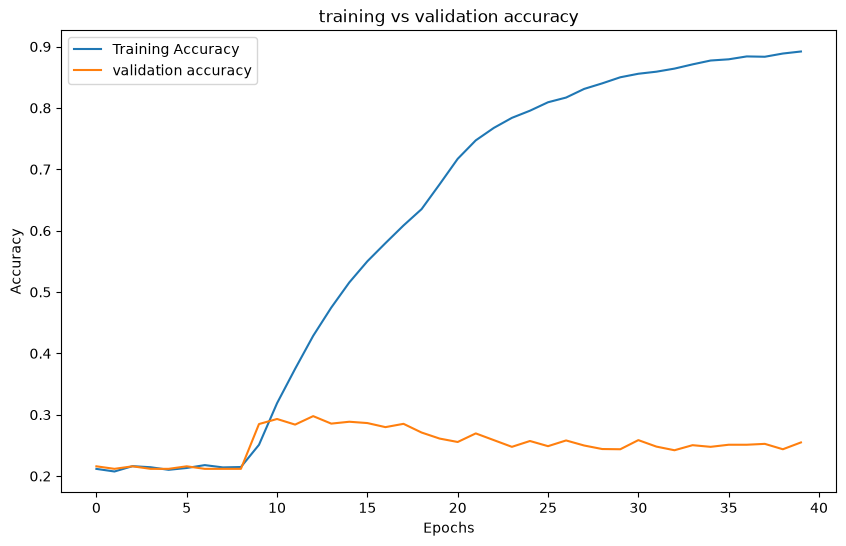

In [73]:
# plot the graph of results 
plt.figure(figsize = (10, 6))
plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "validation accuracy")
plt.title("training vs validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

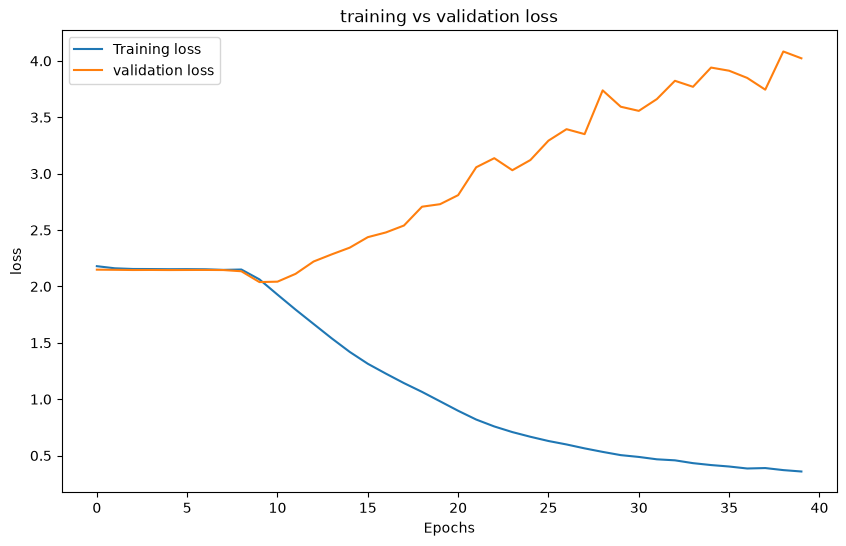

In [74]:
plt.figure(figsize = (10, 6))
plt.plot(history.history["loss"], label = "Training loss")
plt.plot(history.history["val_loss"], label = "validation loss")
plt.title("training vs validation loss")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

In [75]:
# After changing the dropout and changed the number of epochs and introducted early stopage this is what the model produced MUST MENTION DURING ANSWERING THE POE 


In [76]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor = "val_loss",patience = 2, restore_best_weights = True)

In [77]:
history = model.fit(x_train,y_train,validation_data = (x_val,y_val), epochs = 20, batch_size = 64, callbacks = [early_stopping])

Epoch 1/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8949 - loss: 0.3477 - val_accuracy: 0.2452 - val_loss: 4.2106
Epoch 2/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8970 - loss: 0.3419 - val_accuracy: 0.2376 - val_loss: 4.4735
Epoch 3/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8992 - loss: 0.3343 - val_accuracy: 0.2489 - val_loss: 4.2674


In [91]:
#We need to show the difference in the changes 
# include a confusion matrix in the poe 

In [81]:
# OVERALL aCCURACY
# overall accuracy
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose = 0)

print("Test loss: ",test_loss)
print("Test Accuracy", test_accuracy)

Test loss:  4.189289093017578
Test Accuracy 0.24587830901145935


In [82]:
y_probability = model.predict(x_test)
y_pred = np.argmax(y_probability,axis=1)

374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [86]:
accuracy = accuracy_score(y_test, y_pred)

In [88]:
print(accuracy)

0.24587831617708594


In [90]:
Precision = precision_score (y_test,y_pred,average = "macro", zero_division = 0)
print(Precision)

0.14223672607335872


In [95]:
from sklearn.utils.class_weight import compute_class_weight
# assigns largers weights to classes that are less frequent and assigns less weight to bigger classes then we can try to run the model again and check if there is a improvement to the model or not and then we must 
#mention how we tried to improve the model and what happened when we tried to do that 
# try to remove records with the very low classes in the dataset the rerun it with records with really large classes
# this will show us what is affecting the model 
